# Diversity sweep with ADAPTIVE `D`: does diversity still matter once sequencing depth scales with it?

Companion to `diversity_sweep.ipynb`, same `mu=50` (compensated via `N1 = mu * d0 / rho`),
`rho=1e-4`, `T_viab=0.8`, `noise_viab=0.5`, and the same `d0` grid (`5,000` to `1,000,000`) --
**the only thing that changes is `D`**. There, `D=1e8` was held FIXED regardless of `d0`, so
reads-per-sequence (`D/d0`) shrank as the library grew, and the observed decline in signal
fidelity/recovery was, by construction, at least partly just that dilution effect.

Here, `D` scales WITH `d0` instead, at a FIXED target of `READS_PER_SEQ_TARGET = 50,000`
reads/sequence -- not an arbitrary external number, but exactly this project's own long-standing
baseline ratio (`D=1e9` at `d0=20,000` throughout `mu_HEK_multiplicity_sweep.ipynb`,
`T_viab_sweep.ipynb`, etc.). A "smart" experimentalist sequences deeper as the library gets more
diverse, to keep per-variant coverage constant -- this notebook is that scenario.

**But `D` can't scale unboundedly.** A real NGS run has a realistic output ceiling -- this
project's own notebooks never go past `D=1e9` (`D_sequencing_depth_sweep.ipynb`'s own grid tops
out there), which is roughly a realistic single-run depth. So `D` is capped: `D(d0) =
min(READS_PER_SEQ_TARGET * d0, D_MAX)` with `D_MAX=1e9`. Reads/sequence stays flat at `50,000`
only up to `d0 = D_MAX / READS_PER_SEQ_TARGET = 20,000`; PAST that, `D` is pinned at `1e9` and
reads/sequence declines again, exactly like `diversity_sweep.ipynb`'s fixed-`D` case -- but for a
physically grounded reason (sequencer capacity), not an arbitrary flat choice. Every `D` value
used in this sweep stays within the realistic `[1e7, 1e9]` reads range.

**Question.** Up to `d0=20,000`, does diversity have any effect on Pearson `r` and top-1000
recovery when reads/sequence is held perfectly constant? And past `d0=20,000`, once the
realistic sequencer ceiling forces reads/sequence to decline again, do the curves fall off in
the same way `diversity_sweep.ipynb`'s fixed-`D=1e8` case does, or does starting from a much
deeper `D=1e9` at the ceiling buy a wider "safe" range before the decline sets in?

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from flax import nnx
import optax

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp, NUM_AMINO_ACIDS, NUM_POSITIONS

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth weights

Identical real AAV9 `F_viab`/`J_viab` and permuted `F_sel`/`J_sel` as `diversity_sweep.ipynb`
(`F_sel`/`J_sel` are constructed but never used below -- only the viability channel, `target1`,
is swept here). No single fixed `sequences` pool -- each `d0` gets its own inside the sweep loop
(section 5).

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

key_F, key_J = jax.random.split(jax.random.key(0), 2)
sigma_F = jax.random.permutation(key_F, NUM_AMINO_ACIDS)
F_sel   = F_viab[sigma_F, :]
sigma_J = jax.random.permutation(key_J, NUM_AMINO_ACIDS)
J_sel   = J_viab[:, :, sigma_J, :][:, :, :, sigma_J]

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


## 2. Fixed 50,000-sequence evaluation pool (SAME key in every notebook)

A separate, FIXED `50,000`-sequence pool, generated once with a hardcoded key
(`EVAL_POOL_KEY_SEED=999`, `EVAL_POOL_SIZE=50_000` -- the exact same pair of values used in
`deeper_mlp/diversity_sweep_deeper_mlp.ipynb` and every other sweep notebook in this folder),
held out from training entirely. This matters MORE here than in the fixed-`d0` sweeps: at the
smallest `d0` grid points, this notebook's own in-sweep test fold can be too small for
`topk_recovery(..., k=1000)` to mean much (it silently clamps to the whole fold once
`d0/2 < 1000`). Every model trained at every `d0` gets evaluated on this SAME `50,000` sequences,
so top-1000 recovery becomes comparable across the WHOLE `d0` grid and across every other
notebook using the same fixed key, independent of how big or small the training pool itself is.

In [ ]:
EVAL_POOL_KEY_SEED = 999   # fixed across every notebook -- reuse this exact value for comparable numbers
EVAL_POOL_SIZE     = 50_000

def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Noiseless ground-truth score, decoupled from any Protocol instance -- same formula as
    Protocol.compute_score, applied directly to an arbitrary sequence array."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores

eval_sequences = jax.random.randint(jax.random.key(EVAL_POOL_KEY_SEED),
                                     shape=(EVAL_POOL_SIZE, NUM_POSITIONS),
                                     minval=0, maxval=NUM_AMINO_ACIDS)
eval_viab_score = np.asarray(compute_score_array(eval_sequences, F_viab, J_viab))
X_eval = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(eval_sequences)].reshape(EVAL_POOL_SIZE, -1)

print(f"fixed evaluation pool: {EVAL_POOL_SIZE:,} sequences (key seed={EVAL_POOL_KEY_SEED})")
print(f"GT score range on eval pool: [{eval_viab_score.min():.2f}, {eval_viab_score.max():.2f}]")

## 3. Fixed `mu=50`, `rho=1e-4`, `T_viab=0.8`, `noise_viab=0.5`, adaptive (capped) `D`, and the `d0` grid

`D(d0) = min(READS_PER_SEQ_TARGET * d0, D_MAX)` -- linear in `d0` up to the realistic sequencer
ceiling `D_MAX=1e9`, then flat. Reads/sequence (printed below) is therefore only IDENTICAL across
the grid up to `d0=20,000`; past that it necessarily declines, same shape as
`diversity_sweep.ipynb`'s fixed-`D` case but starting from a deeper baseline. Same
`DIVERSITY_GRID` and `K_TOPK=1000` as `diversity_sweep.ipynb` for direct comparison.

In [4]:
RHO_FIXED             = 1e-4
T_VIAB_FIXED          = 0.8
NOISE_VIAB_FIXED      = 0.5
MU_FIXED              = 50
K_TOPK                = 1000
eps                   = 1.0

READS_PER_SEQ_TARGET  = 50_000  # matches this project's own baseline ratio: D=1e9 at d0=20,000
D_MAX                 = 1e9     # realistic single NGS-run ceiling -- never exceeded elsewhere in this project

DIVERSITY_GRID = [5_000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]

print(f"mu={MU_FIXED}  rho={RHO_FIXED}  T_viab={T_VIAB_FIXED}  noise_viab={NOISE_VIAB_FIXED}")
print(f"reads/sequence target: {READS_PER_SEQ_TARGET:,}   D_MAX: {D_MAX:.0e}")
print(f"diversity (d0) grid: {DIVERSITY_GRID}")
for d0_val in DIVERSITY_GRID:
    D_val = min(READS_PER_SEQ_TARGET * d0_val, D_MAX)
    capped = " (CAPPED)" if READS_PER_SEQ_TARGET * d0_val > D_MAX else ""
    print(f"  d0={d0_val:>9,}  ->  N1={MU_FIXED * d0_val / RHO_FIXED:.3e}   D={D_val:.3e}{capped}   "
          f"reads/sequence (D/d0) = {D_val / d0_val:,.0f}")

mu=50  rho=0.0001  T_viab=0.8  noise_viab=0.5
reads/sequence target: 50,000   D_MAX: 1e+09
diversity (d0) grid: [5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
  d0=    5,000  ->  N1=2.500e+09   D=2.500e+08   reads/sequence (D/d0) = 50,000
  d0=   10,000  ->  N1=5.000e+09   D=5.000e+08   reads/sequence (D/d0) = 50,000
  d0=   20,000  ->  N1=1.000e+10   D=1.000e+09   reads/sequence (D/d0) = 50,000
  d0=   50,000  ->  N1=2.500e+10   D=1.000e+09 (CAPPED)   reads/sequence (D/d0) = 20,000
  d0=  100,000  ->  N1=5.000e+10   D=1.000e+09 (CAPPED)   reads/sequence (D/d0) = 10,000
  d0=  200,000  ->  N1=1.000e+11   D=1.000e+09 (CAPPED)   reads/sequence (D/d0) = 5,000
  d0=  500,000  ->  N1=2.500e+11   D=1.000e+09 (CAPPED)   reads/sequence (D/d0) = 2,000
  d0=1,000,000  ->  N1=5.000e+11   D=1.000e+09 (CAPPED)   reads/sequence (D/d0) = 1,000


## 4. `ProfileMLP`: same architecture and adaptive batch size as `diversity_sweep.ipynb`

Identical `ProfileMLP` and warmup-cosine-decay AdamW / early-stopping training loop.
`batch_size = max(256, n_train // 50)`, same reasoning as `diversity_sweep.ipynb` (train fold
spans `2,500` to `500,000` sequences across the grid).

In [5]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x, train: bool, rngs: nnx.Rngs = None):
        x = self.linear1(x)
        self.batchnorm1.use_running_average = not train
        x = self.batchnorm1(x)
        x = nnx.gelu(x)
        x = self.dropout1(x, rngs=rngs) if train else x
        x = self.linear2(x)
        self.batchnorm2.use_running_average = not train
        x = self.batchnorm2(x)
        x = nnx.gelu(x)
        x = self.dropout2(x, rngs=rngs) if train else x
        x = self.linear3(x)
        return x[:, 0]

In [6]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs, best_epoch, final_epoch = float("inf"), None, 0, 0, 0

    for epoch in range(epochs):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm = jax.random.permutation(perm_key, n_train)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n_train - n_train % batch_size, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            train_step(model, optimizer, xb, yb, rngs)

        val_loss = float(eval_step(model, X_val, y_val))
        final_epoch = epoch
        if val_loss < best_val - 1e-6:
            best_val, bad_epochs, best_epoch = val_loss, 0, epoch
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch}, best val MSE = {best_val:.4f}")
                break

    if best_state is not None:
        nnx.update(model, best_state)
    # best_epoch: epoch at which best_val was reached (how long it took to actually converge).
    # final_epoch: last epoch run before stopping (best_epoch + patience, unless it used all `epochs`).
    # steps_per_epoch * (final_epoch + 1) = total optimizer steps actually taken.
    return model, best_val, best_epoch, final_epoch, steps_per_epoch

## 5. Sweep: one fresh pool + one fresh `ProtocolV3` (adaptive `D`) + one fresh `ProfileMLP` per `d0`

Same recipe as `diversity_sweep.ipynb` section 6, except `D = READS_PER_SEQ_TARGET * d0_val` is
now recomputed per grid point instead of using a single fixed value.

At every `d0_val`, the fixed `50,000`-sequence eval pool (section 2) ALSO gets its own independent `ProtocolV3` simulation, at the SAME `D_val = min(READS_PER_SEQ_TARGET * d0_val, D_MAX)` this point uses for training -- unlike `diversity_sweep.ipynb` (fixed `D`, so its eval-pool simulation runs once), `D` here depends on `d0_val`, so this has to be re-simulated every iteration to track it.

In [7]:
records = []
base_key = jax.random.key(1)

for d0_val in tqdm(DIVERSITY_GRID, desc="diversity (d0) sweep, adaptive D"):
    pool_key  = jax.random.fold_in(base_key, d0_val)
    sequences = jax.random.randint(pool_key, shape=(d0_val, NUM_POSITIONS),
                                    minval=0, maxval=NUM_AMINO_ACIDS)
    N1_val = MU_FIXED * d0_val / RHO_FIXED
    D_val  = min(READS_PER_SEQ_TARGET * d0_val, D_MAX)

    protocol = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=N1_val,
            dilution_factor=10, sequences=sequences, D=D_val,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_FIXED, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_FIXED,
            )
    protocol._rho = float(RHO_FIXED)
    viab_score = np.array(protocol.compute_score(F_viab, J_viab))

    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    target1 = np.log((lambda2p + eps) / (lambda0p + eps))

    # Eval pool gets its OWN independent simulation at this SAME D_val (adaptive D depends on
    # d0_val, so unlike diversity_sweep.ipynb this can't be precomputed once outside the loop) --
    # N1 recomputed for the eval pool's own d0=50,000 so it experiences the identical mu=50.
    N1_eval = MU_FIXED * EVAL_POOL_SIZE / RHO_FIXED
    protocol_eval = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=N1_eval,
            dilution_factor=10, sequences=eval_sequences, D=D_val,
            F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
            noise_viab=NOISE_VIAB_FIXED, noise_sel=0.5, T_sel=1, T_viab=T_VIAB_FIXED,
            )
    protocol_eval._rho = float(RHO_FIXED)
    _bio_row_eval, ngs_row_eval = protocol_eval.loop_DE()
    lambda0p_eval, lambda2p_eval, _lambda3p_eval = (np.asarray(a) for a in ngs_row_eval)
    target1_eval = np.log((lambda2p_eval + eps) / (lambda0p_eval + eps))

    X_all = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[np.asarray(sequences)].reshape(d0_val, -1)
    idx_train, idx_test = train_test_split(np.arange(d0_val), test_size=0.5, random_state=0)
    X_train_full, X_test   = X_all[idx_train], X_all[idx_test]
    viab_score_test        = viab_score[idx_test]
    target1_train, target1_test = target1[idx_train], target1[idx_test]

    Xtr, ytr, Xva, yva = split_train_val(X_train_full, target1_train, val_frac=0.15, seed=0)
    batch_size = max(256, len(Xtr) // 50)
    model, val_mse, best_epoch, final_epoch, steps_per_epoch = train_profile_mlp(
        Xtr, ytr, Xva, yva, epochs=300, patience=20, batch_size=batch_size, verbose=False)
    pred_test = np.asarray(predict_log_enrichment(model, jnp.asarray(X_test)))
    pred_eval = np.asarray(predict_log_enrichment(model, jnp.asarray(X_eval)))

    records.append(dict(
        d0=d0_val,
        D=D_val,
        batch_size=batch_size,
        val_mse=val_mse,
        best_epoch=best_epoch,          # epoch at which the best val MSE was reached
        n_epochs_run=final_epoch + 1,   # total epochs before early stop fired
        total_steps=steps_per_epoch * (final_epoch + 1),  # total optimizer updates actually taken
        r_gt_protocol=pearson(viab_score_test, target1_test),
        r_gt_mlp=pearson(viab_score_test, pred_test),
        r_protocol_mlp=pearson(target1_test, pred_test),
        rec_gt_protocol=topk_recovery(viab_score_test, target1_test, k=K_TOPK),
        rec_gt_mlp=topk_recovery(viab_score_test, pred_test, k=K_TOPK),
        rec_protocol_mlp=topk_recovery(target1_test, pred_test, k=K_TOPK),
        rec_gt_mlp_eval=topk_recovery(eval_viab_score, pred_eval, k=K_TOPK),
        r_gt_protocol_eval=pearson(eval_viab_score, target1_eval),
        rec_gt_protocol_eval=topk_recovery(eval_viab_score, target1_eval, k=K_TOPK),
        r_protocol_mlp_eval=pearson(target1_eval, pred_eval),
        rec_protocol_mlp_eval=topk_recovery(target1_eval, pred_eval, k=K_TOPK),
    ))

diversity_sweep_adaptive_df = pd.DataFrame(records)
diversity_sweep_adaptive_df

diversity (d0) sweep, adaptive D: 100%|██████████| 8/8 [1:10:11<00:00, 526.40s/it] 


,d0,D,batch_size,val_mse,best_epoch,n_epochs_run,total_steps,r_gt_protocol,r_gt_mlp,r_protocol_mlp,rec_gt_protocol,rec_gt_mlp,rec_protocol_mlp
0,5000,2.500000e+08,256,1.129930,199,220,1760,0.989982,0.963845,0.966392,0.985,0.915,0.918
1,10000,5.000000e+08,256,0.796333,126,147,2352,0.988669,0.969500,0.973734,0.981,0.898,0.898
2,20000,1.000000e+09,256,0.538945,111,132,4356,0.989468,0.977193,0.981379,0.966,0.865,0.855
3,50000,1.000000e+09,425,0.323371,136,157,7850,0.981756,0.977287,0.988407,0.941,0.837,0.820
4,100000,1.000000e+09,850,0.224198,211,232,11600,0.974845,0.974390,0.991292,0.933,0.815,0.793
5,200000,1.000000e+09,1700,0.170609,241,262,13100,0.964997,0.967147,0.992442,0.922,0.822,0.799
6,500000,1.000000e+09,4250,0.143450,267,288,14400,0.949194,0.953464,0.992486,0.882,0.807,0.771
7,1000000,1.000000e+09,8500,0.141613,236,257,12850,0.933052,0.937300,0.991700,0.842,0.820,0.763


## 6. Pearson correlation vs `d0` (adaptive `D`)

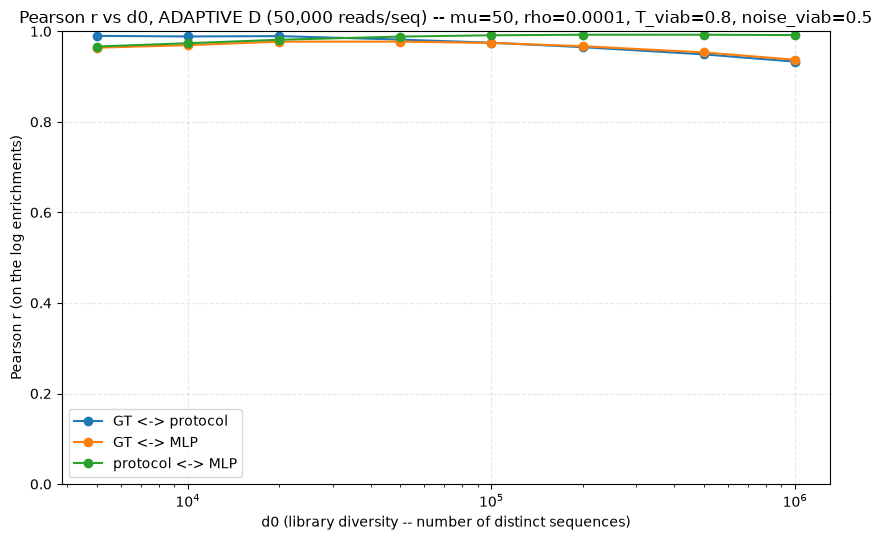

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["r_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("d0 (library diversity -- number of distinct sequences)")
ax.set_ylabel("Pearson r (on the log enrichments)")
ax.set_title(f"Pearson r vs d0, ADAPTIVE D ({READS_PER_SEQ_TARGET:,} reads/seq) -- "
             f"mu={MU_FIXED}, rho={RHO_FIXED:g}, T_viab={T_VIAB_FIXED}, noise_viab={NOISE_VIAB_FIXED}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Top-1000 recovery vs `d0` (adaptive `D`, in-sweep test fold)

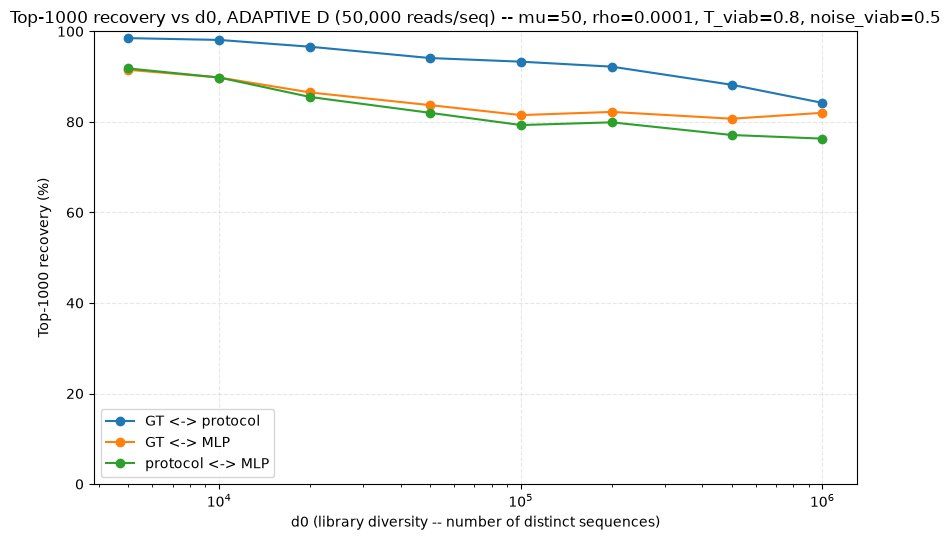

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_protocol"],  "o-", label="GT <-> protocol")
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_mlp"],       "o-", label="GT <-> MLP")
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_protocol_mlp"], "o-", label="protocol <-> MLP")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity -- number of distinct sequences)")
ax.set_ylabel(f"Top-{K_TOPK} recovery (%)")
ax.set_title(f"Top-{K_TOPK} recovery vs d0, ADAPTIVE D ({READS_PER_SEQ_TARGET:,} reads/seq) -- "
             f"mu={MU_FIXED}, rho={RHO_FIXED:g}, T_viab={T_VIAB_FIXED}, noise_viab={NOISE_VIAB_FIXED}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Top-1000 recovery on the FIXED 50,000-sequence eval pool vs `d0`

Same `50,000` sequences (section 2) at every `d0` -- comparable across the whole grid AND across
every other sweep notebook using the same `EVAL_POOL_KEY_SEED=999`/`EVAL_POOL_SIZE=50_000` pair.
Unlike `diversity_sweep.ipynb`'s version of this plot, `GT<->protocol` (gray) is NOT a flat
reference line here -- it's re-simulated at every `d0_val` at that point's own `D_val` (section 5),
so it traces the SAME adaptive-`D`-driven shape as section 7's in-sweep-test-fold curve, just on
the fixed common population instead.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_protocol_eval"], "o-", color="gray", label="GT <-> protocol (fixed eval pool)")
ax.plot(diversity_sweep_adaptive_df["d0"], 100 * diversity_sweep_adaptive_df["rec_gt_mlp_eval"], "o-", color="tab:red", label="GT <-> MLP (fixed eval pool)")
ax.axhline(100 * K_TOPK / EVAL_POOL_SIZE, color="black", lw=1, ls="--", label="random baseline")
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("d0 (library diversity -- number of distinct sequences)")
ax.set_ylabel(f"Top-{K_TOPK} recovery on the fixed {EVAL_POOL_SIZE:,}-sequence eval pool (%)")
ax.set_title("GT <-> MLP recovery on a COMMON, fixed evaluation population")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Training diagnostics: does the model actually get more gradient updates as `d0` grows?

`batch_size = max(256, n_train // 50)` was chosen to keep ~50 steps/epoch (and wall-clock/epoch)
roughly constant across the whole grid -- which means a bigger `d0` gives the model bigger,
smoother batches, NOT necessarily more total gradient updates. If `best_epoch` (epoch the best
val MSE was reached at) stays roughly flat across `d0`, the model converges in about the same
number of update steps regardless of how much data it's given -- consistent with "the model is
too shallow to need more data, so growing `d0` doesn't buy it a better fit, only noisier labels
to fit against." If `best_epoch`/`total_steps` instead grow with `d0`, the model IS making use
of the extra data (taking longer, i.e. more updates, to converge on a better fit).

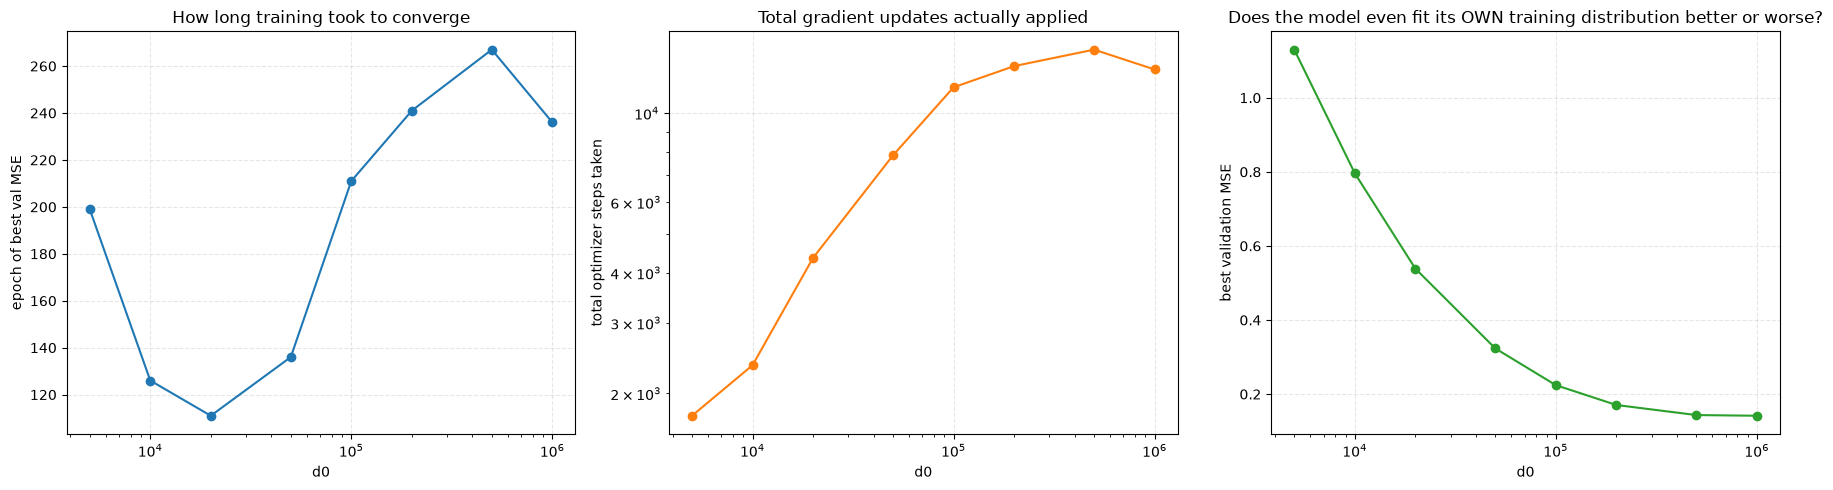

        d0  batch_size  best_epoch  n_epochs_run  total_steps   val_mse
0     5000         256         199           220         1760  1.129930
1    10000         256         126           147         2352  0.796333
2    20000         256         111           132         4356  0.538945
3    50000         425         136           157         7850  0.323371
4   100000         850         211           232        11600  0.224198
5   200000        1700         241           262        13100  0.170609
6   500000        4250         267           288        14400  0.143450
7  1000000        8500         236           257        12850  0.141613


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["best_epoch"], "o-", color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("d0")
ax.set_ylabel("epoch of best val MSE")
ax.set_title("How long training took to converge")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[1]
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["total_steps"], "o-", color="tab:orange")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("d0")
ax.set_ylabel("total optimizer steps taken")
ax.set_title("Total gradient updates actually applied")
ax.grid(True, linestyle="--", alpha=0.3)

ax = axes[2]
ax.plot(diversity_sweep_adaptive_df["d0"], diversity_sweep_adaptive_df["val_mse"], "o-", color="tab:green")
ax.set_xscale("log")
ax.set_xlabel("d0")
ax.set_ylabel("best validation MSE")
ax.set_title("Does the model even fit its OWN training distribution better or worse?")
ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()

print(diversity_sweep_adaptive_df[["d0", "batch_size", "best_epoch", "n_epochs_run", "total_steps", "val_mse"]])

## How to read this

- **Up to `d0=20,000`** (where reads/sequence is genuinely held constant at `50,000`): compare
  directly against `diversity_sweep.ipynb`'s two plots over that same range. If these curves are
  FLAT there while the fixed-`D` ones already decline, the earlier decline was entirely the
  sequencing-budget dilution effect -- diversity itself, at matched per-sequence coverage,
  doesn't make the problem harder.
- **Past `d0=20,000`** (`D` pinned at the realistic ceiling `D_MAX=1e9`, reads/sequence
  necessarily declining again): expect the curves to turn over and decline, similar in SHAPE to
  `diversity_sweep.ipynb`'s decline -- the interesting comparison is WHERE the turnover happens
  and how steep it is, since this sweep starts from a much deeper `D=1e9` at the ceiling instead
  of a flat `D=1e8` throughout.
- If the curves still decline even before `d0=20,000` (while reads/sequence is still perfectly
  flat), diversity has a genuine residual cost beyond dilution -- plausibly the `ProfileMLP`
  facing a more combinatorially varied training distribution, or simply more independent noisy
  draws overall (more chances for the pool's tail to be poorly estimated) even when per-sequence
  read depth is matched.
- `GT <-> MLP` vs `GT <-> protocol` and `protocol <-> MLP`'s expected ordering (lowest of the
  three) follow the same reasoning as every other sweep in this folder.
- **Section 9 checks the training-budget hypothesis directly**: if `best_epoch`/`total_steps` don't grow with `d0`, the model isn't actually exploiting the extra data any more at large `d0` than at small `d0` -- the adaptive `batch_size` (kept to hold steps/epoch roughly constant across the grid) is a likely reason why, and worth revisiting (e.g. a fixed, smaller `batch_size` so steps/epoch scales WITH `d0`) if this turns out to be the dominant explanation for the decline.